In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [2]:
df = pd.read_csv(
    "../data/processed data/model_data.csv"
)

X = df.drop("aqi_category", axis=1)
y = df["aqi_category"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
categorical_features = [
    "country",
    "city"
]

numerical_features = [
    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm25_aqi_value"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [5]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [6]:
rf_model.fit(X_train, y_train)

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'city'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [7]:
y_pred = rf_model.predict(X_test)

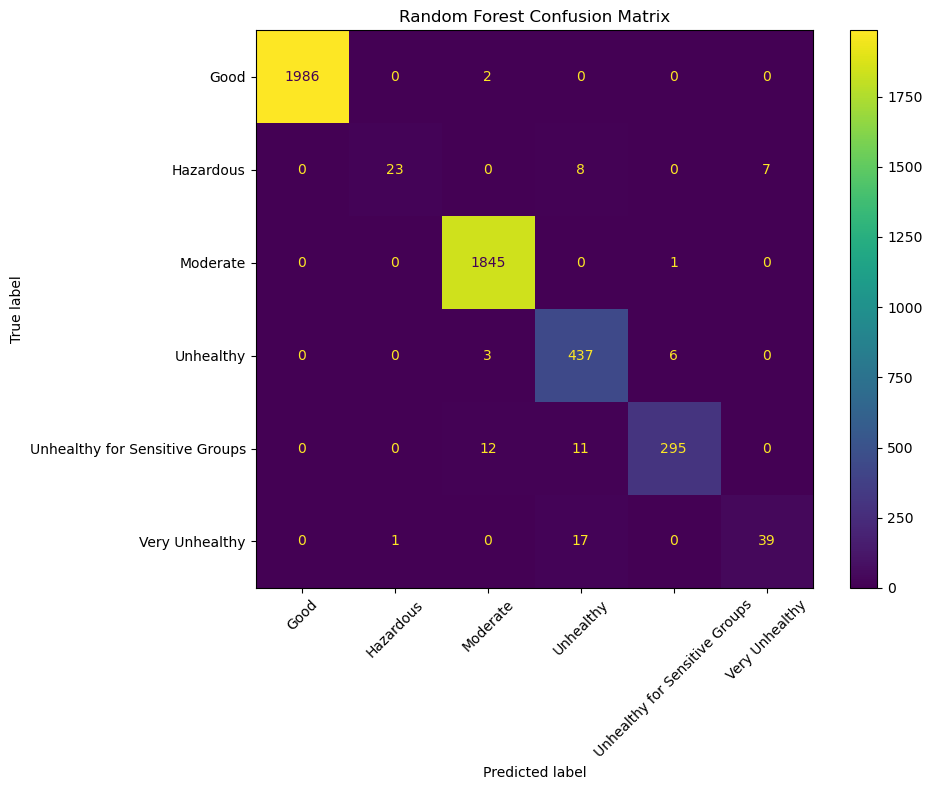

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [9]:
print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1988
                     Hazardous       0.96      0.61      0.74        38
                      Moderate       0.99      1.00      1.00      1846
                     Unhealthy       0.92      0.98      0.95       446
Unhealthy for Sensitive Groups       0.98      0.93      0.95       318
                Very Unhealthy       0.85      0.68      0.76        57

                      accuracy                           0.99      4693
                     macro avg       0.95      0.87      0.90      4693
                  weighted avg       0.99      0.99      0.98      4693



In [10]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.8994176721028867


In [11]:
rf_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [12]:
rf_balanced.fit(X_train, y_train)

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'city'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [13]:
y_pred_balanced = rf_balanced.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred_balanced))

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1988
                     Hazardous       0.94      0.87      0.90        38
                      Moderate       0.98      1.00      0.99      1846
                     Unhealthy       0.93      0.98      0.95       446
Unhealthy for Sensitive Groups       0.98      0.89      0.93       318
                Very Unhealthy       0.93      0.65      0.76        57

                      accuracy                           0.98      4693
                     macro avg       0.96      0.90      0.92      4693
                  weighted avg       0.98      0.98      0.98      4693



In [15]:
balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print("Balanced Random Forest Accuracy:", balanced_accuracy)

Balanced Random Forest Accuracy: 0.9831664180694651


In [16]:
balanced_macro_f1 = f1_score(
    y_test,
    y_pred_balanced,
    average="macro"
)

print("Balanced Random Forest Macro F1:", balanced_macro_f1)

Balanced Random Forest Macro F1: 0.9234214144285501


In [17]:
import joblib


In [18]:
joblib.dump(
    rf_balanced,
    "../models/aqi_category_model.pkl"
)

['../models/aqi_category_model.pkl']

In [19]:
print("Model saved successfully!")

Model saved successfully!
